# VLMでカテゴリ候補を作り、Grounding DINOで物体を検出・集計する

このNotebookは、OpenAI互換VLMから画像内の主要な物体カテゴリを取得し、その候補をGrounding DINOのテキストプロンプトへ渡します。VLMは`label`（見た目の名前）、`canonical_label`（集計用の統一名）、`aliases`（別名）を返し、Grounding DINOはこれらすべてを検索語として使います。検出結果は最終的に`canonical_label`で統一して集計します。

## 1. ライブラリのインポート

In [1]:
import base64
import json
import mimetypes
import os
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor


/home/tadashi/develop/blog-experiments/object-detection/vlm-grounding-dino/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. APIと入力画像の設定

`VLM_API_KEY`と`VLM_MODEL`を環境変数またはこのディレクトリの`.env`に設定してください。OpenAI以外の互換APIを使う場合だけ`VLM_BASE_URL`も設定します。

VLMモデル: gpt-5.6-luna
画像サイズ: 1448 x 1086


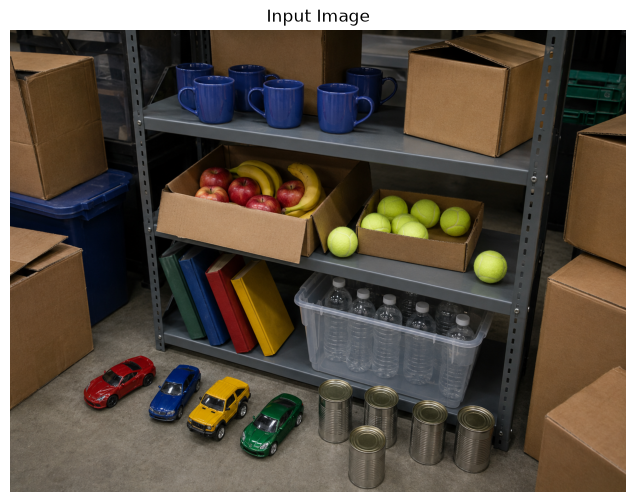

In [ ]:
load_dotenv(dotenv_path=Path('.env'), override=False)

api_key = os.environ.get('VLM_API_KEY')
base_url = os.environ.get('VLM_BASE_URL')
model_name = os.environ.get('VLM_MODEL')
missing = [name for name, value in {
    'VLM_API_KEY': api_key,
    'VLM_MODEL': model_name,
}.items() if not value]
if missing:
    raise EnvironmentError('環境変数が未設定です: ' + ', '.join(missing) + '。README.mdを確認してください。')

image_path = Path('../assets/test2.png')
if not image_path.is_file():
    raise FileNotFoundError(f'入力画像が見つかりません: {image_path.resolve()}')

client_options = {'api_key': api_key}
if base_url:
    client_options['base_url'] = base_url.rstrip('/')
client = OpenAI(**client_options)
image = Image.open(image_path).convert('RGB')
print(f'VLMモデル: {model_name}')
print(f'画像サイズ: {image.size[0]} x {image.size[1]}')
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis('off')
plt.title('Input Image')
plt.show()


## 3. VLMから物体カテゴリ候補を取得

Grounding DINOへの入力互換性のため、短い英語の物体名だけを取得します。さらに、別名や集計用の統一名も取得して、見逃しを減らし最終集計をしやすくします。

In [3]:
mime_type = mimetypes.guess_type(image_path.name)[0] or 'image/png'
image_base64 = base64.b64encode(image_path.read_bytes()).decode('ascii')
image_url = f'data:{mime_type};base64,{image_base64}'

system_prompt = '''
画像内に物理的に存在し、独立して数えられる物体カテゴリだけを列挙してください。
壁・床・棚・空などの背景、文字・ロゴ・模様、物体の部品、写真・絵・ポスター・画面内に描かれた物体は除外します。
個数は回答しません。英語の短いカテゴリ名を使い、同義語もGrounding DINOで使える英語名にします。
説明やMarkdownを含めず、必ず次のJSONだけを返してください。
{"categories":[{"label":"coffee mug","canonical_label":"mug","display_name_ja":"マグカップ","aliases":["cup with handle"],"confidence":0.9}]}
'''

try:
    completion = client.chat.completions.create(
        model=model_name,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': [
                {'type': 'text', 'text': 'この画像にある主要な物体カテゴリを抽出してください。'},
                {'type': 'image_url', 'image_url': {'url': image_url}},
            ]},
        ],
    )
except Exception as error:
    raise RuntimeError('VLM APIの呼び出しに失敗しました。URL・モデル名・認証情報と画像入力対応を確認してください。') from error

raw_response = completion.choices[0].message.content or ''
print(raw_response)

{"categories":[{"label":"mug","canonical_label":"mug","display_name_ja":"マグカップ","aliases":["coffee mug","cup with handle"],"confidence":0.99},{"label":"cardboard box","canonical_label":"cardboard box","display_name_ja":"段ボール箱","aliases":["box","shipping box"],"confidence":0.99},{"label":"apple","canonical_label":"apple","display_name_ja":"リンゴ","aliases":["red apple"],"confidence":0.99},{"label":"banana","canonical_label":"banana","display_name_ja":"バナナ","aliases":["yellow banana"],"confidence":0.99},{"label":"tennis ball","canonical_label":"tennis ball","display_name_ja":"テニスボール","aliases":["ball"],"confidence":0.99},{"label":"book","canonical_label":"book","display_name_ja":"本","aliases":["textbook"],"confidence":0.98},{"label":"plastic bottle","canonical_label":"plastic bottle","display_name_ja":"ペットボトル","aliases":["water bottle","bottle"],"confidence":0.99},{"label":"toy car","canonical_label":"toy car","display_name_ja":"ミニカー","aliases":["car","model car"],"confidence":0.99},{"labe

## 4. 応答を検証し、Grounding DINOのプロンプトに変換

In [4]:
def parse_category_response(text):
    fenced = re.search(r'```(?:json)?\s*(.*?)```', text, flags=re.DOTALL | re.IGNORECASE)
    candidate = fenced.group(1) if fenced else text
    if not fenced:
        start, end = candidate.find('{'), candidate.rfind('}')
        candidate = candidate[start:end + 1] if start >= 0 and end >= start else candidate
    try:
        payload = json.loads(candidate.strip())
    except json.JSONDecodeError as error:
        raise ValueError('VLMの応答をJSONとして解釈できません。上の応答を確認してください。') from error
    if not isinstance(payload, dict) or not isinstance(payload.get('categories'), list):
        raise ValueError('VLM応答には categories 配列が必要です。')
    return payload['categories']

def label_key(label):
    """表記揺れ比較用のキー。toy_car / toy-car / toy car を同じ語として扱う。"""
    return ' '.join(re.sub(r'[_-]+', ' ', str(label).lower()).split())

def normalize_categories(raw_categories):
    normalized = []
    seen = set()
    for index, item in enumerate(raw_categories):
        if not isinstance(item, dict):
            print(f'カテゴリ {index} を無視しました: 辞書ではありません。')
            continue
        # label と canonical_label の処理を修正
        label = ' '.join(str(item.get('label', '')).lower().split())
        canonical = ' '.join(str(item.get('canonical_label') or label).lower().split())
        canonical_key = label_key(canonical)
        if not label or not canonical or canonical_key in seen:
            continue
        # aliases の処理も修正
        aliases = [' '.join(str(value).lower().split()) for value in item.get('aliases', []) if str(value).strip()]
        display_name_ja = ' '.join(str(item.get('display_name_ja', '')).split())
        confidence = float(item.get('confidence', 0.0))
        normalized.append({
            'label': label,
            'canonical_label': canonical,
            'display_name_ja': display_name_ja,
            'aliases': list(dict.fromkeys(aliases)),
            'confidence': confidence
        })
        seen.add(canonical_key)
    return normalized

def labels_for_categories(categories):
    """label, aliases, canonical_label をすべて検索語としてまとめる。"""
    search_labels = []
    canonical_by_label = {}
    all_words = set()
    for category in categories:
        for label in [category['label'], *category['aliases'], category['canonical_label']]:
            key = label_key(label)
            if key not in canonical_by_label:
                search_labels.append(label)
                canonical_by_label[key] = category['canonical_label']
            # 単語レベルでもマッピングを保持（複数ラベル結合対応）
            for word in key.split():
                if word not in canonical_by_label:
                    canonical_by_label[word] = category['canonical_label']
                all_words.add(word)
    return search_labels, canonical_by_label

def canonical_for_label(label, canonical_by_label):
    """検索結果やVLM回答を、カテゴリ発見時に決めた統一名へ戻す。"""
    key = label_key(label)
    if key in canonical_by_label:
        return canonical_by_label[key]
    # 複数ラベル結合の場合、単語ごとに照合
    words = key.split()
    for word in words:
        if word in canonical_by_label:
            return canonical_by_label[word]
    return ' '.join(key.split())

def bbox_iou(left, right):
    """バウンディングボックスのIoUを計算。"""
    x1, y1 = max(left[0], right[0]), max(left[1], right[1])
    x2, y2 = min(left[2], right[2]), min(left[3], right[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    union = max(0, left[2] - left[0]) * max(0, left[3] - left[1]) + max(0, right[2] - right[0]) * max(0, right[3] - right[1]) - intersection
    return intersection / union if union else 0.0

def nms_detections(detections, threshold=0.5):
    """同じ canonical_label で bbox が重複している検出結果を削減。"""
    kept = []
    for candidate in sorted(detections, key=lambda item: item['detector_score'], reverse=True):
        if not any(candidate['canonical_label'] == other['canonical_label'] and bbox_iou(candidate['bbox'], other['bbox']) >= threshold for other in kept):
            kept.append(candidate)
    return kept

# カテゴリのパースと正規化
categories = normalize_categories(parse_category_response(raw_response))
if not categories:
    raise RuntimeError('VLMから有効な物体カテゴリを取得できなかったため、Grounding DINOの推論を実行しません。')

# 検索語と canonical_label のマッピングを作成
labels, canonical_by_label = labels_for_categories(categories)
text_prompt = '. '.join(labels) + '.'

# カテゴリ情報を表示
category_df = pd.DataFrame(categories)
display(category_df)

print(f'検索語数: {len(labels)}')
print(f'カテゴリ数: {len(categories)}')
print(f'Grounding DINOプロンプト（最初100文字）: {text_prompt[:100]}...')

,label,canonical_label,display_name_ja,aliases,confidence
0,mug,mug,マグカップ,"[coffee mug, cup with handle]",0.99
1,cardboard box,cardboard box,段ボール箱,"[box, shipping box]",0.99
2,apple,apple,リンゴ,[red apple],0.99
3,banana,banana,バナナ,[yellow banana],0.99
4,tennis ball,tennis ball,テニスボール,[ball],0.99
5,book,book,本,[textbook],0.98
6,plastic bottle,plastic bottle,ペットボトル,"[water bottle, bottle]",0.99
7,toy car,toy car,ミニカー,"[car, model car]",0.99
8,tin can,tin can,缶,"[can, metal can]",0.99
9,plastic storage bin,plastic storage bin,プラスチック収納箱,"[storage container, plastic container]",0.97


検索語数: 21
カテゴリ数: 10
Grounding DINOプロンプト（最初100文字）: mug. coffee mug. cup with handle. cardboard box. shipping box. apple. red apple. banana. yellow bana...


## 5. Grounding DINOで物体を検出

検索語が多い場合は一度に処理せず、バッチに分けて実行します。これにより、テキスト長の制限を回避し、どの名前で問題が出たかを調べやすくします。

In [5]:
MODEL_ID = 'IDEA-Research/grounding-dino-base'
BOX_THRESHOLD = 0.20
TEXT_THRESHOLD = 0.20
LABELS_PER_BATCH = 20
NMS_THRESHOLD = 0.5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'モデル: {MODEL_ID}')
print(f'デバイス: {device}')
print(f'検索語数: {len(labels)}')
print(f'バッチサイズ: {LABELS_PER_BATCH}')

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device).eval()

# バッチ処理で検出
all_detections = []
batch_metrics = []

for batch_index in range(0, len(labels), LABELS_PER_BATCH):
    batch_labels = labels[batch_index : batch_index + LABELS_PER_BATCH]
    batch_text = '. '.join(batch_labels) + '.'
    print(f'バッチ {batch_index // LABELS_PER_BATCH + 1}: {len(batch_labels)} 件の検索語')
    
    inputs = processor(images=image, text=batch_text, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    
    result = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=BOX_THRESHOLD,
        text_threshold=TEXT_THRESHOLD,
        target_sizes=[image.size[::-1]],
    )[0]
    
    boxes = result['boxes'].cpu().tolist()
    scores = result['scores'].cpu().tolist()
    text_labels = [str(label).lower() for label in result.get('text_labels', [])]
    
    for box, score, label in zip(boxes, scores, text_labels):
        # ラベルを正規化（vlm-grounding-dino-sam2-counting と同じ方法）
        label = ' '.join(label.split())
        all_detections.append({
            'bbox': [float(v) for v in box],
            'detector_label': label,
            'canonical_label': canonical_for_label(label, canonical_by_label),
            'detector_score': float(score)
        })
    
    batch_metrics.append({
        'batch': batch_index // LABELS_PER_BATCH + 1,
        'labels': len(batch_labels),
        'detections': len(boxes)
    })

# NMSで重複を削減
detections = nms_detections(all_detections, threshold=NMS_THRESHOLD)

print(f'総検出数（NMS前）: {len(all_detections)}')
print(f'総検出数（NMS後）: {len(detections)}')
display(pd.DataFrame(batch_metrics))

モデル: IDEA-Research/grounding-dino-base
デバイス: cuda
検索語数: 21
バッチサイズ: 20
バッチ 1: 20 件の検索語
バッチ 2: 1 件の検索語
総検出数（NMS前）: 70
総検出数（NMS後）: 52


,batch,labels,detections
0,1,20,68
1,2,1,2


## 6. 結果の可視化と集計

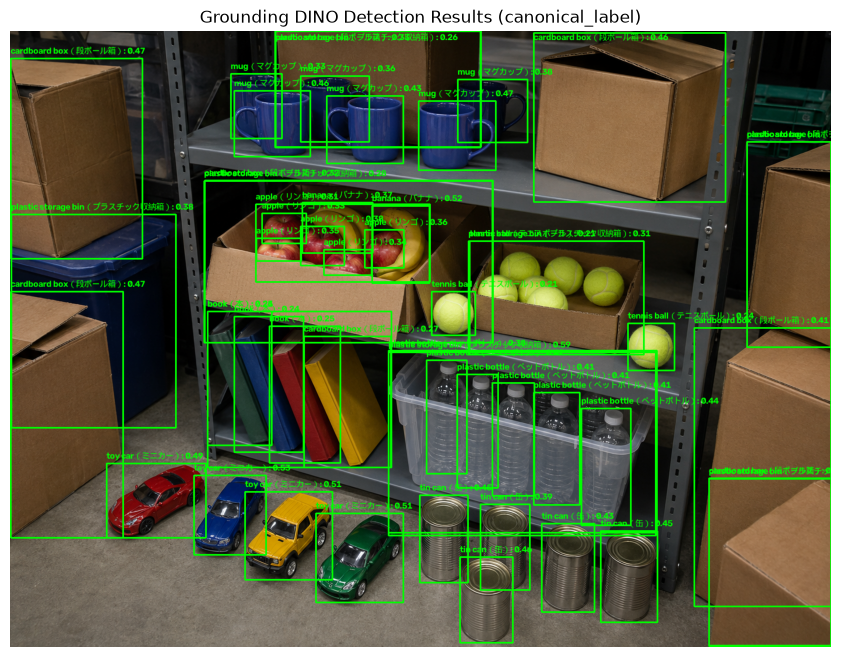

# 検出結果（検出スコア順）


,display_label,detector_label,canonical_label,detector_score,bbox
0,plastic storage bin（プラスチック収納箱）,plastic container,plastic storage bin,0.592011,"[666.9473876953125, 565.8474731445312, 1138.25..."
1,toy car（ミニカー）,toy car model car,toy car,0.532998,"[323.64111328125, 782.7958984375, 451.09750366..."
2,banana（バナナ）,banana yellow banana,banana,0.516538,"[638.4613037109375, 308.0284118652344, 738.779..."
3,toy car（ミニカー）,toy car model car,toy car,0.514995,"[413.75103759765625, 811.98095703125, 568.0711..."
4,toy car（ミニカー）,toy car model car,toy car,0.514165,"[538.8720703125, 850.150634765625, 693.1986694..."
5,toy car（ミニカー）,toy car model car,toy car,0.490874,"[170.4730224609375, 762.2726440429688, 344.589..."
6,cardboard box（段ボール箱）,cardboard box shipping box,cardboard box,0.470529,"[0.7471103072166443, 459.1673889160156, 199.33..."
7,mug（マグカップ）,mug,mug,0.469040,"[720.2963256835938, 122.7313461303711, 855.927..."
8,cardboard box（段ボール箱）,cardboard box shipping box,cardboard box,0.465984,"[0.9341710805892944, 47.91347885131836, 232.57..."
9,mug（マグカップ）,mug,mug,0.463636,"[394.50665283203125, 105.07784271240234, 529.1..."


# 最終集計結果（検出数順）


,統一名（canonical_label）,表示名,検出数
3,cardboard box,cardboard box（段ボール箱）,9
6,plastic storage bin,plastic storage bin（プラスチック収納箱）,7
5,plastic bottle,plastic bottle（ペットボトル）,6
0,apple,apple（リンゴ）,6
4,mug,mug（マグカップ）,6
8,tin can,tin can（缶）,5
9,toy car,toy car（ミニカー）,4
2,book,book（本）,4
7,tennis ball,tennis ball（テニスボール）,3
1,banana,banana（バナナ）,2


In [9]:
annotated_frame = np.array(image).copy()

# canonical_label から display_name_ja へのマッピングを作成
canonical_to_ja = {cat['canonical_label']: cat.get('display_name_ja', '') for cat in categories}

for detection in detections:
    x1, y1, x2, y2 = [int(round(v)) for v in detection['bbox']]
    canonical = detection['canonical_label']
    japanese = canonical_to_ja.get(canonical, '')
    display_label = f"{canonical}（{japanese}）" if japanese else canonical
    cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    text = f'{display_label}: {detection["detector_score"]:.2f}'
    cv2.putText(annotated_frame, text, (x1, max(y1 - 8, 16)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_frame)
plt.axis('off')
plt.title('Grounding DINO Detection Results (canonical_label)')
plt.show()

# データフレームを作成
df_data = []
for detection in detections:
    canonical = detection['canonical_label']
    japanese = canonical_to_ja.get(canonical, '')
    display_label = f"{canonical}（{japanese}）" if japanese else canonical
    df_data.append({
        'display_label': display_label,
        'detector_label': detection['detector_label'],
        'canonical_label': canonical,
        'detector_score': detection['detector_score'],
        'bbox': detection['bbox']
    })

df = pd.DataFrame(df_data)
if df.empty:
    print('閾値を満たす検出結果はありません。')
else:
    print('# 検出結果（検出スコア順）')
    display(df.sort_values('detector_score', ascending=False).reset_index(drop=True))
    # canonical_label で集計（日本語併記）
    counts = df.groupby('canonical_label').size().reset_index(name='検出数')
    display_labels = df.groupby('canonical_label')['display_label'].first().reset_index(name='表示名')
    summary_df = counts.merge(display_labels, on='canonical_label')
    summary_df = summary_df.sort_values('検出数', ascending=False)
    summary_df.columns = ['統一名（canonical_label）', '検出数', '表示名']
    summary_df = summary_df[['統一名（canonical_label）', '表示名', '検出数']]
    print('# 最終集計結果（検出数順）')
    display(summary_df)